In [1]:
import pandas as pd
import numpy as np

df=pd.read_pickle(f"./df.pkl")

In [2]:
df_pdm = df[df["dm"] == 1]

# 무작위 10명 추출 (항상 같은 결과)
df_test = df_pdm.sample(
    n=10,
    random_state=42
).reset_index(drop=True)

print(df_test.shape)

(10, 26)


In [3]:
df_test

,dm,sex,age,edu,income,job,glu,hba1c,hdl,tg,...,wk_mvpa_play,wk_walk,wk_sleep,stress,wk_break,wk_lunch,wk_dinner,wk_veg1,wk_veg2,wk_fruit
0,1,2.0,63.0,3.0,2.0,3.0,109.0,6.0,42.0,303.0,...,0.0,420.0,240.0,1.0,6.0,6.0,6.0,21.0,21.0,14.000
1,1,2.0,60.0,2.0,2.0,6.0,97.0,5.7,33.0,1201.0,...,0.0,0.0,360.0,2.0,0.0,6.0,6.0,14.0,14.0,5.500
2,1,1.0,58.0,1.0,5.0,5.0,107.0,5.5,49.0,209.0,...,10.0,210.0,360.0,2.0,6.0,6.0,6.0,14.0,14.0,0.625
3,1,1.0,50.0,4.0,4.0,2.0,108.0,5.1,41.0,230.0,...,0.0,360.0,360.0,2.0,6.0,6.0,6.0,21.0,21.0,1.000
4,1,1.0,69.0,4.0,3.0,1.0,100.0,5.3,55.0,190.0,...,0.0,420.0,360.0,2.0,6.0,6.0,6.0,21.0,21.0,3.000
5,1,1.0,55.0,3.0,3.0,5.0,98.0,5.9,43.0,110.0,...,0.0,0.0,420.0,1.0,6.0,6.0,6.0,21.0,21.0,3.000
6,1,1.0,41.0,3.0,3.0,6.0,107.0,5.1,61.0,96.0,...,150.0,150.0,480.0,2.0,6.0,6.0,6.0,3.0,3.0,7.000
7,1,2.0,54.0,4.0,3.0,5.0,112.0,5.9,50.0,183.0,...,20.0,175.0,420.0,3.0,6.0,6.0,6.0,14.0,14.0,7.000
8,1,2.0,58.0,4.0,3.0,1.0,118.0,5.8,79.0,103.0,...,0.0,125.0,420.0,2.0,6.0,6.0,6.0,14.0,14.0,7.000
9,1,1.0,63.0,2.0,4.0,3.0,97.0,5.7,49.0,150.0,...,0.0,0.0,480.0,1.0,1.5,6.0,6.0,14.0,14.0,7.000


In [4]:
df_test['wk_smk']

0      0.0
1     49.0
2      0.0
3    119.0
4      0.0
5     49.0
6     70.0
7      0.0
8      0.0
9      0.0
Name: wk_smk, dtype: float64

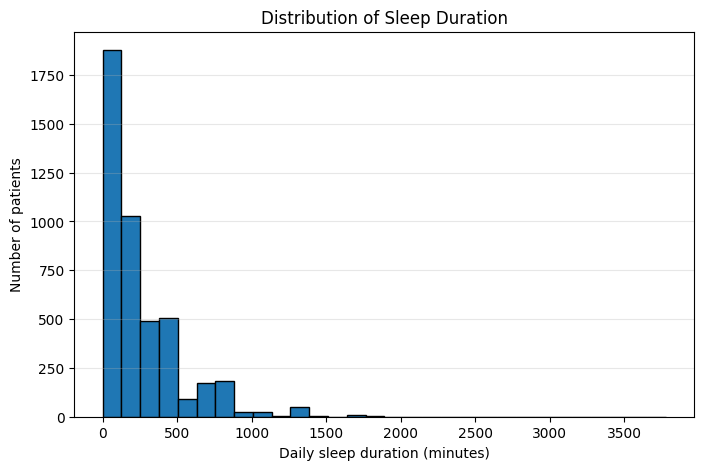

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_pdm["wk_walk"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Daily sleep duration (minutes)")
plt.ylabel("Number of patients")
plt.title("Distribution of Sleep Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()

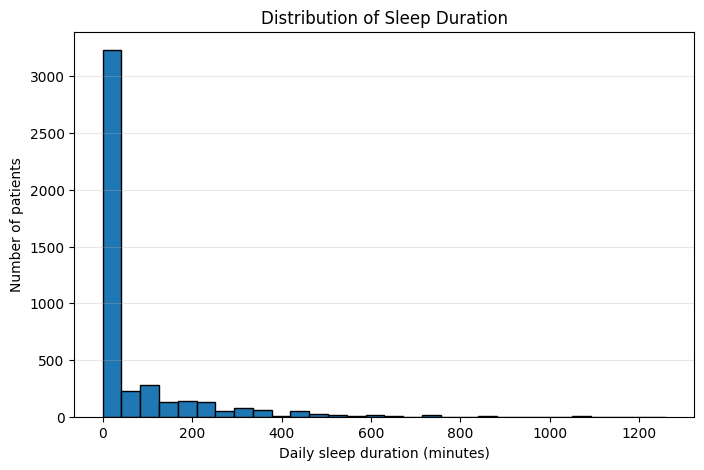

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_pdm["wk_mvpa_play"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Daily sleep duration (minutes)")
plt.ylabel("Number of patients")
plt.title("Distribution of Sleep Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [7]:
from docx import Document
from docx.shared import Pt
from PFPD import PFPD

def get_references_from_context(ctx_item):
    refs = []
    for g in ctx_item.get("guidelines", []):
        meta = g.get("metadata", {})
        ref = meta.get("reference", "")
        if ref and ref not in refs:
            refs.append(ref)
    return "; ".join(refs)


def add_patient_recommendation_to_doc(doc, patient_no, X, current_score, deltas, final_score, recommendation_result, retrieved_context):
    doc.add_heading(f"Patient {patient_no}", level=1)

    doc.add_paragraph(f"Current progression score: {current_score:.3f}")
    doc.add_paragraph(f"Final progression score after lifestyle optimization: {final_score:.3f}")

    doc.add_heading("Recommended lifestyle modifications", level=2)

    for i, (item,ctx) in enumerate(zip(recommendation_result["action_items"],retrieved_context)):
        meta=ctx["item"]
        
        variable=meta["variable"]
        description=meta["description"]
        current_value=meta["current_value"]
        
        reference = get_references_from_context(ctx)
        
        doc.add_paragraph(f"{i+1}. {variable}", style=None)
        doc.add_paragraph(f"Variable: {description}")
        doc.add_paragraph(f"Current value: {current_value}")
        doc.add_paragraph(f"Recommendation: {item.get('recommendation based on delta')}")
        doc.add_paragraph(f"Rationale: {item.get('rationale')}")
        doc.add_paragraph(f"Reference: {reference}")

    doc.add_paragraph(
        "Disclaimer: These recommendations are generated to support lifestyle modification "
        "and do not replace professional medical advice. Please consult your healthcare provider "
        "before making major lifestyle changes."
    )


def generate_word_report_for_40_patients(df_test, output_path="recommendation_report_40_patients.docx"):
    pro = PFPD()
    doc = Document()

    doc.add_heading("Personalized Lifestyle Recommendation Report", level=0)

    for idx, row in df_test.iterrows():
        patient_no = idx + 1

        # row를 기존 X 형태의 dict로 변환
        X = row.to_dict()

        # 필요 없는 컬럼 제거: dm, id 등 모델에 안 들어가는 변수 제거
        for col in ["dm", "dm_binary", "id", "ID", "patient_id"]:
            X.pop(col, None)

        current_score = pro.dbs_progression(X)

        deltas, final_score = pro.lifestyle_rec(X)

        recommendation_result, retrieved_context = pro.make_patient_friendly_recommendation(X, deltas)

        add_patient_recommendation_to_doc(
            doc=doc,
            patient_no=patient_no,
            X=X,
            current_score=current_score,
            deltas=deltas,
            final_score=final_score,
            recommendation_result=recommendation_result,
            retrieved_context=retrieved_context
        )

        # 한 페이지당 2명
        if patient_no % 2 == 0 and patient_no != len(df_test):
            doc.add_page_break()
        else:
            doc.add_paragraph("\n" + "-" * 80 + "\n")

    doc.save(output_path)
    print(f"Saved: {output_path}")

In [8]:
generate_word_report_for_40_patients(
    df_test,
    output_path="recommendation_report_10_patients_epsilon5_lam0.1_lr0.005_step400.docx"
)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\p

Personalized Lifestyle Recommendation

[1] wk_sleep
------------------------------------------------------------
Variable           : Average daily sleep duration (minutes)
Current value      : 240.0
Recommendation     : Increase your average daily sleep duration by about 1 hour to reach approximately 5 hours per day.
Rationale             : According to ADA guidelines, both short sleep duration (less than 6 hours) and poor overall sleep quality are associated with a higher risk of developing type 2 diabetes. Sleep-promoting routines such as establishing a regular bedtime and rise time, creating a conducive sleep environment, and avoiding caffeine, nicotine, spicy foods, and alcohol before bedtime can help improve sleep quality and duration.
Reference          : Sleep Characteristics Associated With Increased Risk of Type 2 Diabetes, section 3, ADA Standards of Care (2026); Psychological Care, section 5, ADA Standards of Care (2026)

Disclaimer
These recommendations are generated to su

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_break
------------------------------------------------------------
Variable           : Number of days you eat breakfast each week
Current value      : 0.0
Recommendation     : Increase the number of days you eat breakfast each week from none to about 6 days per week.
Rationale             : Eating regular meals and planning meals ahead supports healthy nutrition patterns. A variety of eating patterns including Mediterranean-style and plant-based diets with fruits, vegetables, legumes, and minimal processed foods are recommended for diabetes prevention. Including heart-healthy foods and minimizing processed foods helps improve overall health.
Reference          : Medical Nutrition Therapy - Nutrition Behaviors to encourage, section 5, ADA Standards of Care (2026); Nutrition, section 3, ADA Standards of Care (2026)

[2] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

...

Personalized Lifestyle Recommendation

[1] wk_mvpa_play
------------------------------------------------------------
Variable           : Weekly minutes of moderate-to-vigorous physical activity
Current value      : 20.0
Recommendation     : Increase your weekly moderate-to-vigorous physical activity by about 210 minutes to reach around 230 minutes per week.
Rationale             : At least 150 minutes per week of moderate-intensity physical activity is recommended for diabetes prevention. The activity should be distributed throughout the week with a minimum frequency of three times per week and at least 10 minutes per session. In addition to aerobic activity, resistance training can also be included. People not meeting activity guidelines should increase physical activities such as walking, yoga, housework, gardening, swimming, and dancing.
Reference          : The diabetes prevention program, section 3, ADA Standards of Care (2026); Physical Activity, section 5, ADA Standards of Care

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1 to 4
Current value      : 2.0
Recommendation     : Try to lower your stress level from 2 to about 1 by incorporating regular relaxation exercises like meditation or yoga, taking meaningful breaks for yourself, and spending time on activities that help you recharge.
Rationale             : Reducing stress is important because diabetes stress, anxiety, and depression can significantly increase A1C levels and decrease quality of life, as emphasized in the ADA Standards of Care. Additionally, calming activities such as quick walks, relaxation exercises, and self-care strategies like limiting alcohol and caffeine, eating healthy food, and getting enough sleep can help manage stress effectively according to the CDC guidelines on Mental Health.
Reference          : Diabetes and Mental Health (2024), Centers for Disease Control a

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_walk
------------------------------------------------------------
Variable           : Weekly minutes of walking
Current value      : 0.0
Recommendation     : Gradually increase your walking time to about 20-22 hours per week.
Rationale             : The ADA Standards of Care recommend reducing sedentary time and breaking up long periods of inactivity by standing, walking, or performing light activities to support glycemic control and vascular health. Additionally, breaking up prolonged sedentary periods lowers post-meal glucose levels.
Reference          : Physical Activity, section 5, ADA Standards of Care (2026); The diabetes prevention program, section 3, ADA Standards of Care (2026)

[2] wk_fruit
------------------------------------------------------------
Variable           : Weekly frequency of fruit consumption
Current value      : 7.0
Recommendation     : Increase your fruit consumption to about 3 times daily, focusing on whole fru

In [9]:
# Patient 10만 다시 생성/출력

from PFPD import PFPD
from llm_writer import print_recommendation

pro = PFPD()

# df_test에서 10번째 환자
row = df_test.iloc[9]
X = row.to_dict()

# 모델에 안 들어가는 컬럼 제거
for col in ["dm", "dm_binary", "id", "ID", "patient_id"]:
    X.pop(col, None)

current_score = pro.dbs_progression(X)
deltas, final_score = pro.lifestyle_rec(X)

# recommendation 생성
recommendation_result, retrieved_context = pro.make_patient_friendly_recommendation(X, deltas)

# mismatch 확인
vars_from_context = [ctx["item"]["variable"] for ctx in retrieved_context]
vars_from_llm = [item["variable"] for item in recommendation_result["action_items"]]

print("context:", vars_from_context)
print("llm    :", vars_from_llm)

assert vars_from_context == vars_from_llm, "Variable mismatch occurred"

print("Current score:", current_score)
print("Final score:", final_score)

print_recommendation(recommendation_result, retrieved_context)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\p

Personalized Lifestyle Recommendation

[1] wk_walk
------------------------------------------------------------
Variable           : Weekly minutes of walking
Current value      : 0.0
Recommendation     : Increase your walking by about 20 minutes every day, aiming for a total of around 1260 minutes per week.
Rationale             : The guidelines recommend reducing sedentary time and breaking up prolonged sitting by engaging in light physical activities like walking to gain glycemic and cardiometabolic benefits, including improved vascular function. Additionally, breaking up prolonged sedentary time lowers postprandial glucose levels, supporting diabetes prevention.
Reference          : Physical Activity, section 5, ADA Standards of Care (2026); The diabetes prevention program, section 3, ADA Standards of Care (2026)

[2] wk_fruit
------------------------------------------------------------
Variable           : Weekly frequency of fruit consumption
Current value      : 7.0
Recommendati

In [10]:
print(f"current score: {pro.dbs_progression(X)}")
deltas, final_score = pro.lifestyle_rec(X)

print(f"recommend: {deltas}")
print(f"final score: {final_score}")

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

current score: 50.04879379272461


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-p

recommend: {'wk_alc': -0.18749963702472883, 'wk_mvpa_play': -3.329001856400282e-06, 'wk_walk': 1260.0, 'wk_sleep': -120.0, 'wk_break': -1.500000355197244, 'wk_dinner': -3.5776724815368652, 'wk_veg1': 2.350919723510742, 'wk_veg2': 7.0, 'wk_fruit': 14.0}
final score: 44.83798599243164


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0


In [11]:
X

{'sex': 1.0,
 'age': 63.0,
 'edu': 2.0,
 'income': 4.0,
 'job': 3.0,
 'glu': 97.0,
 'hba1c': 5.7,
 'hdl': 49.0,
 'tg': 150.0,
 'ldl': 169.0,
 'sbp': 148.5,
 'wc': 98.2,
 'bmi': 26.29146539685447,
 'wk_smk': 0.0,
 'wk_alc': 0.1875,
 'wk_mvpa_play': 0.0,
 'wk_walk': 0.0,
 'wk_sleep': 480.0,
 'stress': 1.0,
 'wk_break': 1.5,
 'wk_lunch': 6.0,
 'wk_dinner': 6.0,
 'wk_veg1': 14.0,
 'wk_veg2': 14.0,
 'wk_fruit': 7.0}